Install Packages

In [35]:
!pip3 install langgraph openai chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-api
    Found 

Initialize the client LLM

In [12]:
from google.colab import userdata
from openai import OpenAI

GROQ_API_KEY = userdata.get('GROQ_API_KEY')
client = OpenAI(
    api_key= GROQ_API_KEY, base_url = "https://api.groq.com/openai/v1"
)


In [13]:
def call_llm(prompt, system="You are a helpful assistant."):
  """Simple helper to call the LLM"""
  response = client.chat.completions.create(
      model="openai/gpt-oss-120b",
      messages=[
          {"role": "system", "content": system},
          {"role": "user", "content": prompt}
      ],
      temperature=0.2
  )

  return response.choices[0].message.content

print("Setup completed")

Setup completed


In [14]:
call_llm("What is the capital of France?")

'The capital of France is **Paris**.'

##State definition

### [START] → [GREET] → [UPPERCASE] → [END]

In [15]:
state = {}
state["Question"] = "hello"
state["Qustion"] = "hello"
state['anything'] = 123

state

{'Question': 'hello', 'Qustion': 'hello', 'anything': 123}

In [16]:
from typing import TypedDict

class SimpleState(TypedDict):
  name: str
  greeting: str
  final_output:str


In [17]:
def greet(state):
  "Node 1:Creating a greeting from the name"
  name = state["name"]
  greetings = f"Hello {name}! welcome to LangGraph Tutorial"
  return {"greeting": greetings}

In [18]:
def uppercase(state):
  "Node 2: Convert greeting to uppercase"
  result = state['greeting'].upper()
  print(f" [UPPEFCASE] Converted to uppercase")
  return {"final_output": result}

In [19]:
from langgraph.graph import StateGraph , START, END

In [20]:
graph = StateGraph(SimpleState)

# Add Nodes

graph.add_node("greet", greet)
graph.add_node("uppercase", uppercase)

# Adding edges

graph.add_edge(START, "greet")
graph.add_edge("greet", "uppercase")
graph.add_edge("uppercase", END)

app = graph.compile()

print("Graph is built")


Graph is built


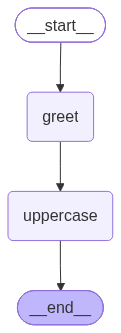

In [21]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

# Execute the flow chart

In [22]:
result = app.invoke({"name": "Balaji"})

print(result)

 [UPPEFCASE] Converted to uppercase
{'name': 'Balaji', 'greeting': 'Hello Balaji! welcome to LangGraph Tutorial', 'final_output': 'HELLO BALAJI! WELCOME TO LANGGRAPH TUTORIAL'}


In [23]:
print(f"\nFinal result")
print(f" Name: {result['name']}")
print(f" Greeting: {result['greeting']}")
print(f" Final Output: {result['final_output']}")


Final result
 Name: Balaji
 Greeting: Hello Balaji! welcome to LangGraph Tutorial
 Final Output: HELLO BALAJI! WELCOME TO LANGGRAPH TUTORIAL


# Using LLM as a nodes

In [24]:
class LLMState(TypedDict):
  question: str
  topic: str
  answer: str

#Node1 : Analyze the question
def analyze_question(state):
  """Identify the topic of the question."""
  question = state['question']
  topic = call_llm(f"What is the main topic of this question? Reply with one word only: {question}",
                   system="You classify questions into topics. Reply wth exactly one word.")

  print(f"[ANALYZE] Topic: {topic}")
  return {'topic': topic.strip()}

def respond(state):
  "Answer the question"
  answer = call_llm(f"Topic: {state['topic']}\nQuestion: {state['question']}\nGive brief answer.",
                    system="you are a helpful assistant. Be concise (2-3 sentences max).")

  print(f" [RESPOND] Answer generated")
  return {'answer': answer}

llm_graph = StateGraph(LLMState)
llm_graph.add_node("analyze", analyze_question)
llm_graph.add_node("respond", respond)
llm_graph.add_edge(START, "analyze")
llm_graph.add_edge("analyze", "respond")
llm_graph.add_edge("respond", END)

llm_app = llm_graph.compile()
print("LLM graph ready!")

LLM graph ready!


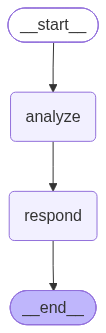

In [25]:
from IPython.display import display, Image

display(Image(llm_app.get_graph().draw_mermaid_png()))

In [26]:
# Test it
result = llm_app.invoke({"question": "What is the capital of France?"})
print(f"\nQuestion: {result['question']}")
print(f"Topic: {result['topic']}")
print(f"Answer: {result['answer']}")

[ANALYZE] Topic: Geography
 [RESPOND] Answer generated

Question: What is the capital of France?
Topic: Geography
Answer: The capital of France is **Paris**. It is the country’s largest city and a major cultural, political, and economic hub.


In [27]:
# Another question

result = llm_app.invoke({"question": "What is the bias varience tradeoff?"})
print(f"\nQuestion: {result['question']}")
print(f"Topic: {result['topic']}")
print(f"Answer: {result['answer']}")

[ANALYZE] Topic: MachineLearning
 [RESPOND] Answer generated

Question: What is the bias varience tradeoff?
Topic: MachineLearning
Answer: The bias‑variance tradeoff describes how a model’s error splits into **bias** (error from overly simple assumptions that cause under‑fitting) and **variance** (error from sensitivity to training‑set noise that causes over‑fitting). Reducing bias usually increases variance and vice‑versa, so the goal is to find a balance that minimizes total prediction error.


# Conditional Edges - Branching Logic

---
## Part 4: Conditional Edges -Branching Logic

This is where LangGraph shines, Instead of "always go to the next node, We can say:

"If the Intent is billing, go to the billing handler. If HR, go to the HR handler."

---


In [28]:
class RouterState(TypedDict):
  question: str
  intent: str
  context: str
  answer: str

def classify_intent(state):
  """ Classify the user's question into billing/hr/general"""
  question = state['question']
  intent = call_llm(
      f"Classify this question into exactly one category: billing, hr, or general.\n\nQuestion: {question}\n\nReply with ONLY the category word (billing, hr, or general):",
        system="You classify questions. Reply with exactly one word: billing, hr, or general."
  )
  intent = intent.strip().lower()
  if intent not in ["billing", "hr", "general"]:
    intent = "general"
  print(f" [CLASSIFY] Intent: {intent}")
  return {'intent': intent}

In [29]:
def handle_billing(state):
  """ Answer billing related questions"""
  answer = call_llm(
      state['question'],
      system= "You are a billing support agent. Answer questions about subscriptions, pricing, payments, and refunds. Be helpful and concise."
  )
  print(f"  [BILLING] Answered")
  return {"answer": answer, "context": "billing_docs"}

In [30]:
def handle_hr(state):
  answer = call_llm(
      state['question'],
      system="You are an HR assistant. Answer questions about leave policy, WFH, probation, and company policies. Be helpful and concise"
  )
  print(f"  [HR] Answered")
  return {"answer": answer, "context": "hr_docs"}

In [31]:
def handle_genral(state):
  answer = call_llm(
      state['question'],
      system = "You are a helpful assistant. Answer the question concisely."
  )
  print(f" [GENERAL] answered")
  return {"answer": answer, "context": "general_knowledge"}

In [32]:
def route_by_intent(state):
  intent = state["intent"]
  if intent == "billing":
    return "handle_billing"
  elif intent == 'hr':
    return "handle_hr"
  elif intent == "general":
    return "handle_general"

```
                    ┌── billing → [BILLING] ──┐
[CLASSIFY] ─────── ├── hr      → [HR]      ──├──→ [RESPOND]
                    └── general → [GENERAL] ──┘

In [33]:
router_graph = StateGraph(RouterState)

router_graph.add_node("classify", classify_intent)
router_graph.add_node("handle_billing", handle_billing)
router_graph.add_node("handle_hr", handle_hr)
router_graph.add_node("handle_general", handle_genral)

router_graph.add_edge(START, "classify")

router_graph.add_conditional_edges(
    "classify",
    route_by_intent,
     {
        "handle_billing": "handle_billing",
        "handle_hr": "handle_hr",
        "handle_general": "handle_general"
     }

)

router_graph.add_edge("handle_billing", END)
router_graph.add_edge("handle_hr", END)
router_graph.add_edge("handle_general", END)

router_app = router_graph.compile()
print("Router graph is ready")
print("Flow classify -> (billing | hr | general) -> END")


Router graph is ready
Flow classify -> (billing | hr | general) -> END


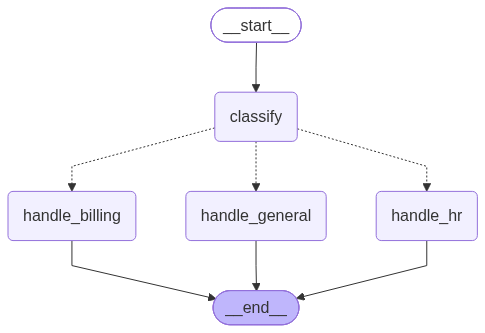

In [34]:
from IPython.display import display, Image

display(Image(router_app.get_graph().draw_mermaid_png()))

In [35]:
print("=" * 60)
result = router_app.invoke({"question": "How do I cancel my subscription?"})
print(f"\nIntent: {result['intent']}")
print(f"Answer: {result['answer']}")
print("=" * 60)

 [CLASSIFY] Intent: billing
  [BILLING] Answered

Intent: billing
Answer: Sure! Here’s a quick guide to cancel your subscription:

1. **Log in to your account**  
   Go to the website or app where you originally signed up.

2. **Navigate to the “Billing” or “Subscription” section**  
   - On the web: Click your profile/avatar → **Account Settings** → **Billing**.  
   - In the mobile app: Tap the menu (☰) → **Settings** → **Subscription**.

3. **Find the active plan**  
   You should see your current plan listed with a “Cancel” or “Manage” button.

4. **Click “Cancel Subscription”**  
   - Confirm the cancellation when prompted.  
   - You may be asked for a reason (optional).

5. **Check for confirmation**  
   - You’ll receive an email confirming the cancellation and the date your access will end (usually the end of the current billing cycle).  
   - Keep that email for your records.

**A few extra notes**

- **Timing:** Cancel before the next billing date to avoid being charged for 

In [36]:
# Test: HR question
print("═" * 60)
result = router_app.invoke({"question": "How many sick leave days do I get?"})
print(f"\nIntent: {result['intent']}")
print(f"Answer: {result['answer']}")

════════════════════════════════════════════════════════════
 [CLASSIFY] Intent: hr
  [HR] Answered

Intent: hr
Answer: The number of sick‑leave days you’re entitled to depends on your company’s specific policy, but most organizations follow one of these common structures:

| Policy Type | Typical Annual Allocation |
|-------------|---------------------------|
| **Standard** | 10 – 12 paid sick days per calendar year |
| **Accrual‑Based** | 0.8 – 1.0 day earned each month (≈9‑12 days/year) |
| **Senior/Long‑Tenure** | Additional 1‑2 days after 3‑5 years of service |
| **Carry‑Over** | Often up to 5 unused days may roll over to the next year (subject to a cap) |

**Key points to keep in mind**

1. **Eligibility** – Most full‑time employees become eligible on their first day of employment; part‑time staff may receive a prorated amount.
2. **Documentation** – A medical certificate is usually required for absences of 3 + consecutive days (or per your manager’s request).
3. **Notification**

In [37]:
# Test: General question
print("═" * 60)
result = router_app.invoke({"question": "What is machine learning?"})
print(f"\nIntent: {result['intent']}")
print(f"Answer: {result['answer']}")

════════════════════════════════════════════════════════════
 [CLASSIFY] Intent: general
 [GENERAL] answered

Intent: general
Answer: Machine learning is a branch of artificial intelligence that enables computers to learn patterns and make decisions from data without being explicitly programmed. By training algorithms on examples, the system improves its performance on tasks such as classification, prediction, or clustering as it encounters more data.


## Add retry logic in the llm call

In [38]:
import time

def generate_with_retry(state):
  """Generate answer with retry logic inside the node."""
  question = state['question']
  for attempt in range(3):
    try:
      answer = call_llm(question)
      print(f" [GENERATE] Success on attempt {attempt + 1}")
      return {"answer": answer}
    except Exception as e:
      print(f" [GENERATE] Attempt {attempt + 1} failed: {e}")
      if attempt < 2:
        wait =  2 ** attempt
        print(f" [GENERATE] waiting {wait}s before retry...")
        time.sleep(wait)

  # All retries failed
  return {"answer": "Sorry, I couldn't generate an answer. Please try again later."}

print(f" Retry node defined")
print("   Pattern: try → fail → wait 1s → try → fail → wait 2s → try → give up")


 Retry node defined
   Pattern: try → fail → wait 1s → try → fail → wait 2s → try → give up


#Mini-Build — Customer Support Router with RAG

Let's combine everything: classification + RAG retrieval + conditional routing.

This is a real-world pattern — a customer support bot that routes questions to the right knowledge base.

```
[CLASSIFY] → billing? → [SEARCH billing docs] → [GENERATE answer]
           → hr?      → [SEARCH hr docs]      → [GENERATE answer]
           → general? → [LLM answers directly]
```

In [39]:
import chromadb

chroma_client = chromadb.Client()

try:
  chroma_client.delete_collection("billing_docs")
  chroma_client.delete_collection("hr_docs")
except:
  pass

billing_collection = chroma_client.create_collection("billing_docs")
hr_collection = chroma_client.create_collection("hr_docs")

# Add some billing knowledge
billing_docs = [
    "Monthly subscriptions can be cancelled anytime from Settings > Billing > Cancel. You will retain access until the end of your current billing period.",
    "Refunds for annual plans are available within 30 days of purchase. After 30 days, annual subscriptions are non-refundable.",
    "Payment methods accepted: credit card (Visa, Mastercard), debit card, UPI, and net banking. International cards are supported.",
    "If a payment fails, the system retries 3 times over 7 days. After that, your account enters a 14-day grace period.",
    "Upgrade from Starter to Business plan takes effect immediately with prorated charges for the remaining billing period.",
]

# Add some HR knowledge
hr_docs = [
    "All full-time employees get 24 days of paid annual leave per year, accruing at 2 days per month.",
    "Sick leave is 12 days per year. More than 3 consecutive days requires a medical certificate.",
    "Work from home is available up to 2 days per week (Wednesday and Friday preferred) after completing the 6-month probation period.",
    "Probation period is 6 months. During probation, either party can terminate with 15 days notice.",
    "Annual performance reviews happen in March. Ratings: Exceptional, Exceeds, Meets, Needs Improvement, Unsatisfactory.",
]

billing_collection.add(documents = billing_docs, ids=[f"b{i}" for i in range(len(billing_docs))])
hr_collection.add(documents = hr_docs, ids=[f"h{i}" for i in range(len(hr_docs))])

print(f"✅ Billing KB: {len(billing_docs)} docs")
print(f"✅ HR KB: {len(hr_docs)} docs")

✅ Billing KB: 5 docs
✅ HR KB: 5 docs


In [43]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# ──────────────────────────────────────
# The Complete Customer Support Graph
# ──────────────────────────────────────

class SupportState(TypedDict):
    question: str
    intent: str
    context: str
    answer: str
    source: str

def classify(state):
    """Classify the question."""
    intent = call_llm(
        f"Classify this customer question into: billing, hr, or general.\nQuestion: {state['question']}\nReply with ONE word only:",
        system="Reply with exactly one word: billing, hr, or general."
    ).strip().lower()
    if intent not in ["billing", "hr", "general"]:
        intent = "general"
    print(f"  [CLASSIFY] → {intent}")
    return {"intent": intent}

def search_billing(state):
    """Search billing documents."""
    results = billing_collection.query(query_texts=[state["question"]], n_results=2)
    context = "\n".join(results["documents"][0])
    print(f"  [BILLING RAG] Retrieved {len(results['documents'][0])} chunks")
    return {"context": context, "source": "billing_docs"}

def search_hr(state):
    """Search HR documents."""
    results = hr_collection.query(query_texts=[state["question"]], n_results=2)
    context = "\n".join(results["documents"][0])
    print(f"  [HR RAG] Retrieved {len(results['documents'][0])} chunks")
    return {"context": context, "source": "hr_docs"}

def answer_general(state):
    """Answer general questions directly."""
    answer = call_llm(state["question"])
    print(f"  [GENERAL] Answered directly")
    return {"answer": answer, "source": "general_knowledge", "context": ""}

def generate_answer(state):
    """Generate answer from retrieved context."""
    answer = call_llm(
        f"Context:\n{state['context']}\n\nQuestion: {state['question']}\n\nAnswer using only the context above. Be concise.",
        system="Answer customer questions using only the provided context. If context doesn't have the answer, say so."
    )
    print(f"  [GENERATE] Answer ready")
    return {"answer": answer}

def route(state):
    """Route based on intent."""
    # The route function should return the 'key' from the conditional_edges mapping
    # not the destination node name directly.
    return state["intent"]

# Build the graph
support_graph = StateGraph(SupportState)

support_graph.add_node("classify", classify)
support_graph.add_node("search_billing", search_billing)
support_graph.add_node("search_hr", search_hr)
support_graph.add_node("answer_general", answer_general)
support_graph.add_node("generate", generate_answer)

# Edges
support_graph.add_edge(START, "classify")

support_graph.add_conditional_edges(
    "classify",
    route,
    {
        "billing": "search_billing",
        "hr":      "search_hr",
        "general": "answer_general",
    }
)

support_graph.add_edge("search_billing", "generate")
support_graph.add_edge("search_hr",      "generate")
support_graph.add_edge("answer_general", END)
support_graph.add_edge("generate",       END)

support_app = support_graph.compile()
print("✅ Customer Support Router ready!")

✅ Customer Support Router ready!


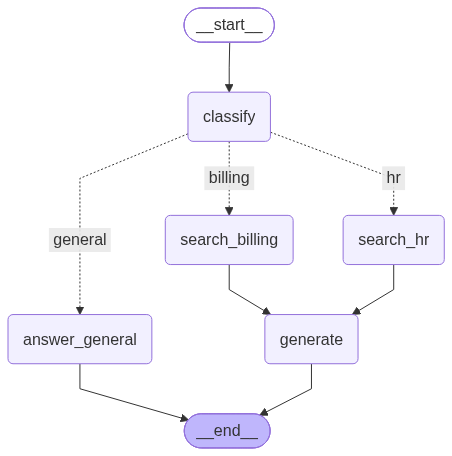

In [41]:
from IPython.display import Image, display

display(Image(support_app.get_graph().draw_mermaid_png()))

In [44]:
# Test: Billing question
print("═" * 60)
result = support_app.invoke({"question": "How do I cancel my subscription?"})
print(f"\nIntent: {result['intent']}")
print(f"Answer: {result['answer']}")

════════════════════════════════════════════════════════════
  [CLASSIFY] → billing
  [BILLING RAG] Retrieved 2 chunks
  [GENERATE] Answer ready

Intent: billing
Answer: Go to **Settings → Billing → Cancel**. This will cancel your subscription, and you’ll keep access until the end of the current billing period.
